In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import os
os.environ["SCPRINTER_DATA"] = "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/scPrinter/scprinter/docs/reference/Datasets"
import scprinter as scp

# Load data
attr_file = "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/model/HSC_Oligo_LoRA_fold0-divine-gorge-4.pt_HSC_Oligo_LoRA_olig1/model_OPC.attr.just_sum.shap_hypo_0-30_.0.85.npz"
peaks_file = "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/scPrinter/Oligo/seq2print/regions_olig1.bed"

data = np.load(attr_file)
attributions = data['arr_0']  # (16, 1840)

peaks = pd.read_table(peaks_file, sep="\t", header=None)
peaks.columns = ["chrom", "peak_start", "peak_end"]
peaks["summit"] = (peaks["peak_start"] + peaks["peak_end"]) // 2

/cluster2/huanglab/jiamao/conda/envs/scprinter/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/cluster2/huanglab/jiamao/conda/envs/scprinter/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. Th

In [2]:
# Load genome
genome = scp.genome.hg38

# 1. Trim to central 800 bp (drop 520 bp each side)
target_len = 800
trim_start = (1840 - target_len) // 2  # 520
trim_end = trim_start + target_len + 1 # 1320
attr_trimmed = attributions[:, trim_start:trim_end]  # (16, 801)
print(f"Trimmed attribution shape: {attr_trimmed.shape}")

Trimmed attribution shape: (4, 801)


In [3]:

# 2. Map trimmed window to genomic coordinates
def get_genomic_coords(region_idx):
    """Genomic coordinates for trimmed sequence"""
    peak = peaks.iloc[region_idx]
    # 1840 bp window centered on summit; trimmed = middle 800 bp
    # genomic_start offset from summit (see code)
    genomic_start = peak["summit"] - target_len // 2  # summit - 400
    genomic_end = genomic_start + target_len  # summit + 400
    return peak["chrom"], genomic_start, genomic_end


In [4]:
def plot_sequence_track_fixed(region_idx, ax=None):
    """Sequence track plot (fixed)"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(20, 6))
    
    chrom, genomic_start, genomic_end = get_genomic_coords(region_idx)
    
    # Sequence and attribution arrays
    seq = genome.fetch_seq(chrom, genomic_start, genomic_end + 1).upper()
    attr_1d = attr_trimmed[region_idx]
    
    # Per-base colors
    base_colors = {
        'A': '#007A3F',
        'G': '#F4A02D',
        'C': '#375BA4',
        'T': '#E82634',
        'N': '#C7C7C7'
    }
    
    max_height = np.abs(attr_1d).max() * 1.1
    
    # Draw per-base bars
    for i, (base, score) in enumerate(zip(seq, attr_1d)):
        height = abs(score)
        color = base_colors.get(base, base_colors['N'])
        alpha = min(0.9, 0.5 + abs(score) / max_height * 0.4)
        
        # Bars anchored at zero
        if score >= 0:
            # Positive: stack up from 0
            y_bottom = 0
            y_top = height
        else:
            # Negative: stack down from 0
            y_bottom = -height
            y_top = 0
        
        # Draw rectangles without edges
        rect = Rectangle((i - 0.45, y_bottom), 0.9, y_top - y_bottom,
                         facecolor=color, edgecolor='none', alpha=alpha)  # edgecolor='none'
        ax.add_patch(rect)
    
    # Zero line
    ax.axhline(y=0, color='black', linewidth=1.5, linestyle='-', zorder=10)
    
    # Axis limits
    ax.set_xlim(-0.5, len(seq) - 0.5)
    ax.set_ylim(-max_height, max_height)
    ax.set_xlabel(f'Position (bp) - {chrom}:{genomic_start}-{genomic_end}', fontsize=11)
    ax.set_ylabel('Attribution Score', fontsize=11)
    ax.set_title(f'Region {region_idx}: {chrom}:{genomic_start}-{genomic_end}', fontsize=13, fontweight='bold')
    
    # Optional grid
    ax.grid(True, alpha=0.2, linestyle=':', linewidth=0.5, axis='y')
    
    # Legend (colors only)
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color, label=base, alpha=0.7) 
                      for base, color in base_colors.items() if base != 'N']
    ax.legend(handles=legend_elements, loc='upper right', framealpha=0.9)
    
    plt.tight_layout()
    return ax

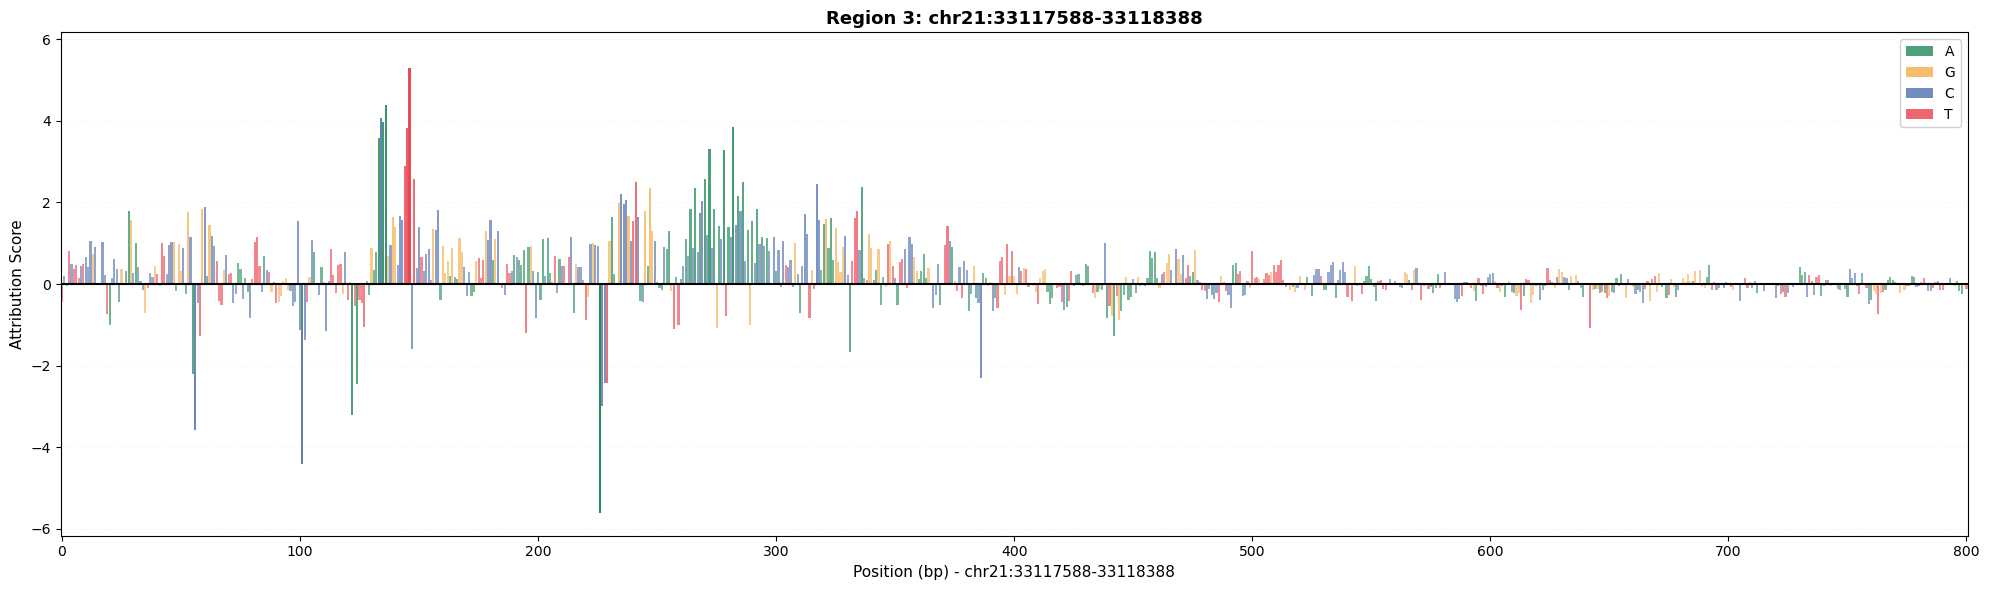

In [9]:
# Plot
plot_sequence_track_fixed(3)
plt.savefig('OLIG1_sequence_track_region3.pdf', dpi=300, bbox_inches='tight')
plt.show()